<a href="https://colab.research.google.com/github/Student-NitinRaj/Data-Analysis-HUB-/blob/main/Insurance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_excel("/content/Insurance-analysis.xlsx")

In [7]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## 1. Initial Data Overview and Inspection
Let's get a first look at the dataset: its dimensions, column types, and basic descriptive statistics.

In [9]:
# Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
display(df.head())

First 5 rows of the DataFrame:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [10]:
# Display the shape of the DataFrame (number of rows, number of columns)
print("\nShape of the DataFrame:")
print(df.shape)


Shape of the DataFrame:
(1338, 7)


In [11]:
# Display concise summary of the DataFrame, including data types and non-null values
print("\nInformation about the DataFrame columns:")
df.info()


Information about the DataFrame columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [12]:
# Display descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
display(df.describe())


Descriptive statistics for numerical columns:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [13]:
# Display descriptive statistics for categorical columns
print("\nDescriptive statistics for categorical columns:")
display(df.describe(include='object'))


Descriptive statistics for categorical columns:


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


## 2. Missing Values and Duplicates Check
It's important to identify and handle any missing data or duplicate records to maintain data quality and ensure accurate analysis.

In [14]:
# Check for missing values in each column
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [15]:
# Check for duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Number of duplicate rows:
1


In [16]:
# If duplicates exist, you might want to drop them.
# For now, let's just show how many unique rows there would be.
if df.duplicated().sum() > 0:
    print("\nDataFrame after dropping duplicates (if any):")
    df_cleaned = df.drop_duplicates()
    print(f"Original shape: {df.shape}, New shape after dropping duplicates: {df_cleaned.shape}")
else:
    print("\nNo duplicate rows found.")


DataFrame after dropping duplicates (if any):
Original shape: (1338, 7), New shape after dropping duplicates: (1337, 7)


In [17]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 5. Exploratory Data Analysis (EDA) - Feature Relationships
Understanding the relationships between features is crucial. We'll start by looking at the correlations between numerical variables.

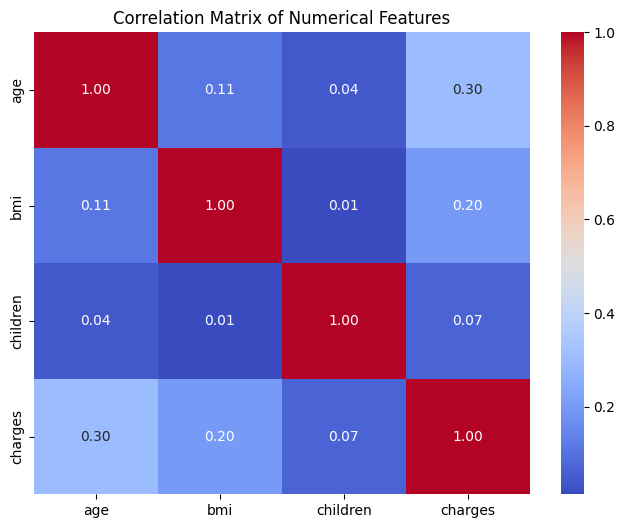

In [18]:
# Calculate the correlation matrix for numerical features
corr_matrix = df[['age', 'bmi', 'children', 'charges']].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

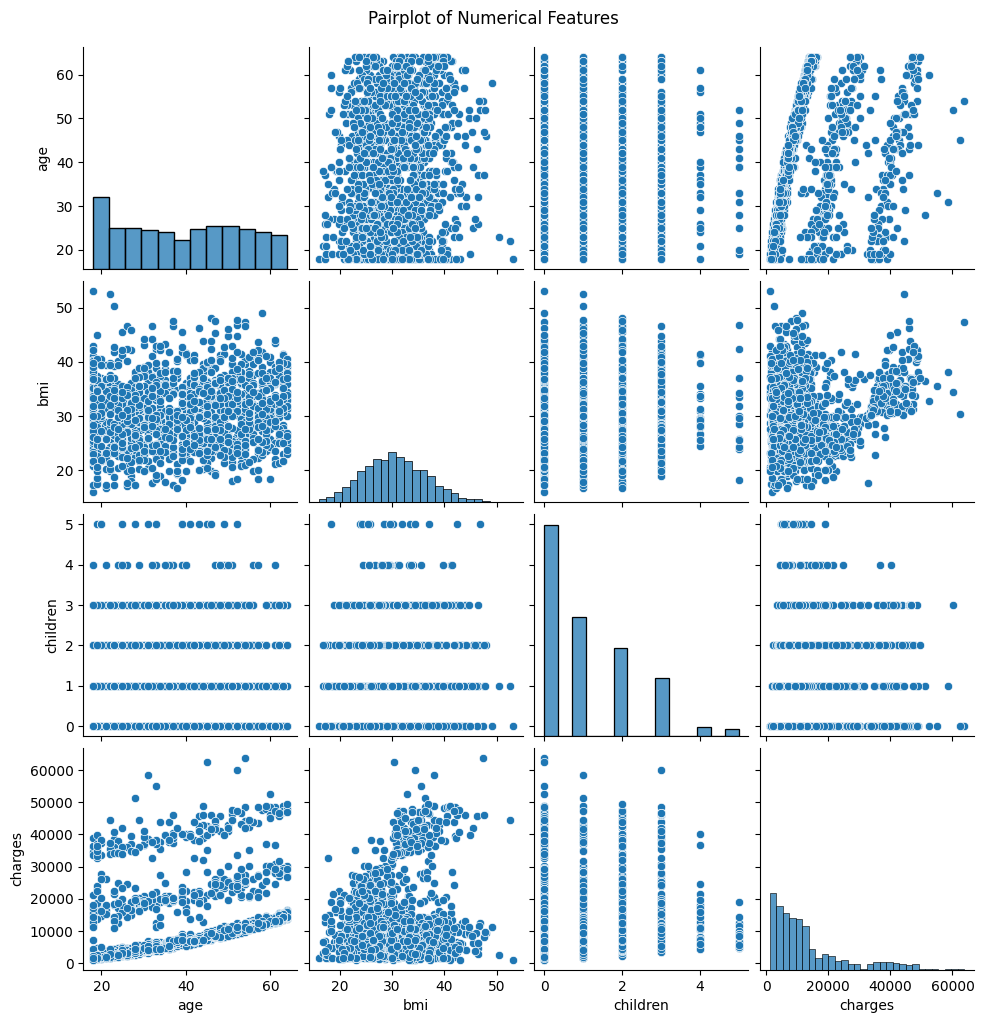

In [19]:
# Pairplot to visualize relationships between numerical features
sns.pairplot(df[['age', 'bmi', 'children', 'charges']])
plt.suptitle('Pairplot of Numerical Features', y=1.02) # Adjust suptitle position
plt.show()

## 6. Exploratory Data Analysis (EDA) - Relationship between Charges and Categorical Features
Let's visualize how insurance 'charges' vary across different categories of 'sex', 'smoker', 'children', and 'region'. This helps us identify potential influences of these categorical factors on the cost of insurance.

/tmp/ipykernel_1316/2248266167.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex', y='charges', data=df, palette='pastel')
/tmp/ipykernel_1316/2248266167.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='pastel')
/tmp/ipykernel_1316/2248266167.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='region', y='charges', data=df, palette='pastel')


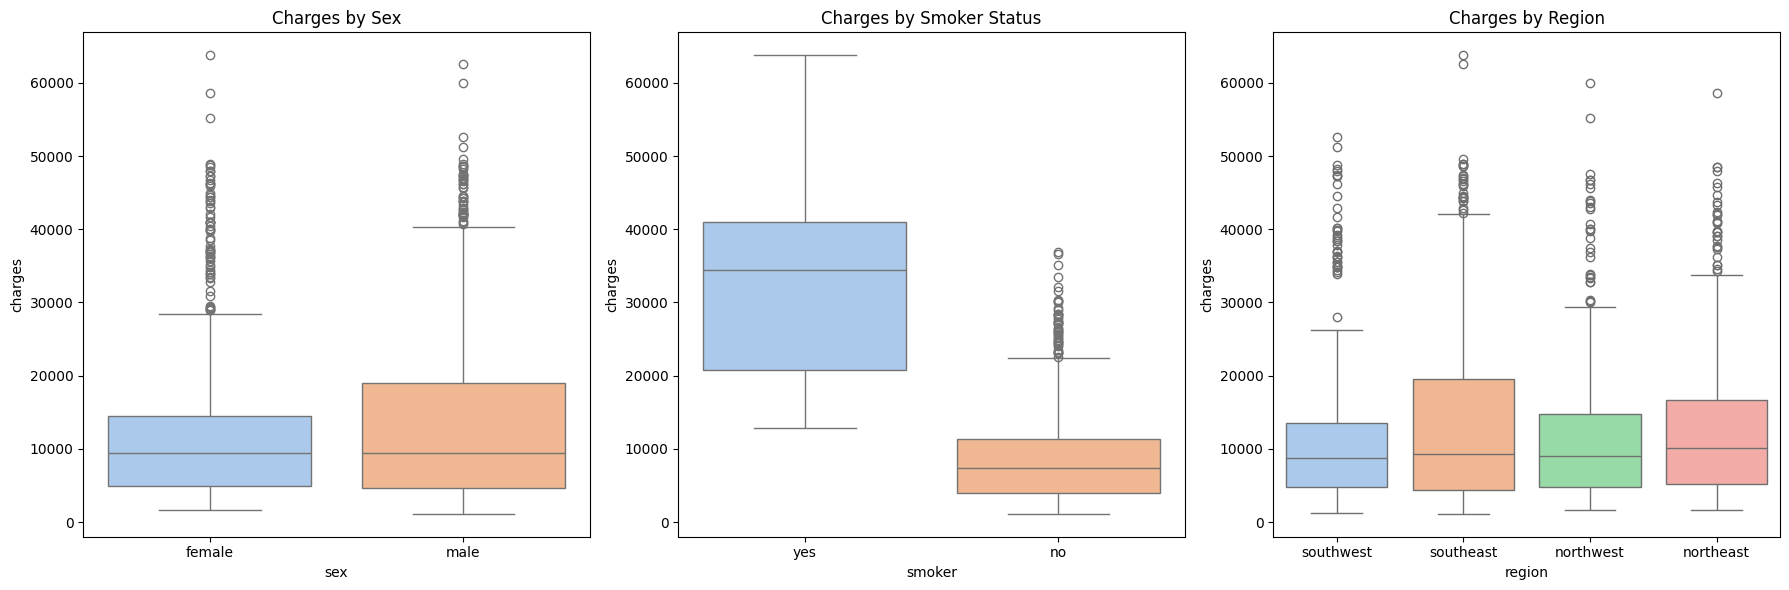

/tmp/ipykernel_1316/2248266167.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='children', y='charges', data=df, palette='pastel')


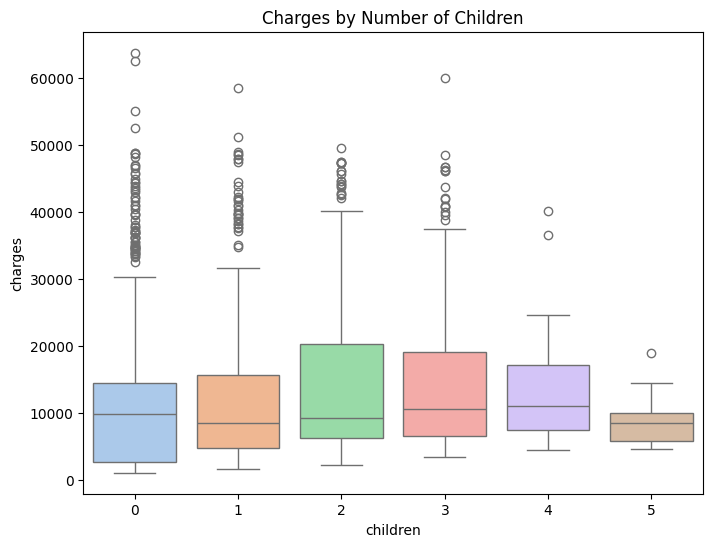

In [20]:
plt.figure(figsize=(18, 6))

# Charges by Sex
plt.subplot(1, 3, 1)
sns.boxplot(x='sex', y='charges', data=df, palette='pastel')
plt.title('Charges by Sex')

# Charges by Smoker Status
plt.subplot(1, 3, 2)
sns.boxplot(x='smoker', y='charges', data=df, palette='pastel')
plt.title('Charges by Smoker Status')

# Charges by Region
plt.subplot(1, 3, 3)
sns.boxplot(x='region', y='charges', data=df, palette='pastel')
plt.title('Charges by Region')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
# Charges by Number of Children
sns.boxplot(x='children', y='charges', data=df, palette='pastel')
plt.title('Charges by Number of Children')
plt.show()

## 7. Exploratory Data Analysis (EDA) - Average Charges by Region
To further understand regional variations, let's visualize the average charges for each region.

/tmp/ipykernel_1316/53121639.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='region', y='charges', data=avg_charges_by_region, palette='coolwarm')


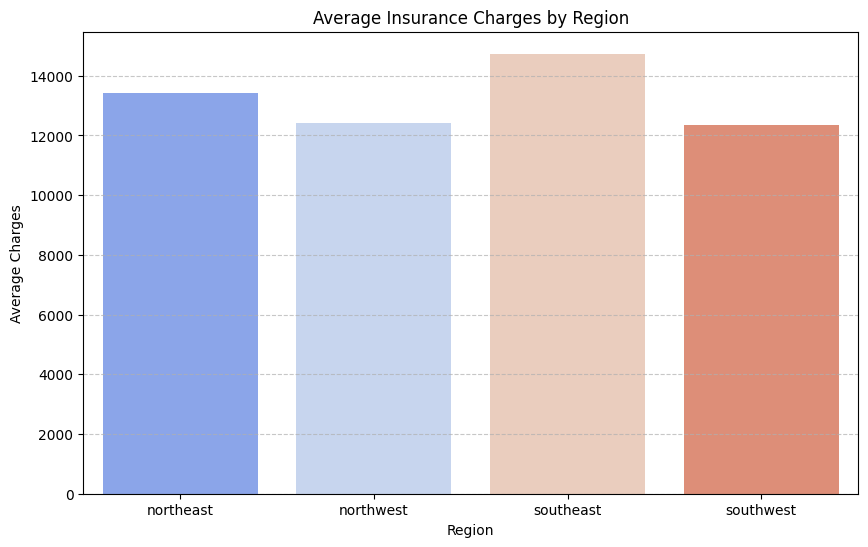

In [24]:
# Calculate the average charges per region
avg_charges_by_region = df.groupby('region')['charges'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='region', y='charges', data=avg_charges_by_region, palette='coolwarm')
plt.title('Average Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Average Charges')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 8. Exploratory Data Analysis (EDA) - Average Charges by Gender
Let's visualize the average charges for different genders to see if there's any significant difference.

In [ ]:
# Calculate the average charges per gender
avg_charges_by_sex = df.groupby('sex')['charges'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='sex', y='charges', data=avg_charges_by_sex, palette='coolwarm')
plt.title('Average Insurance Charges by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Charges')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 9. Exploratory Data Analysis (EDA) - BMI vs. Charges by Smoker Status
Let's visualize the relationship between 'bmi' and 'charges', differentiated by 'smoker' status. This can reveal significant patterns.

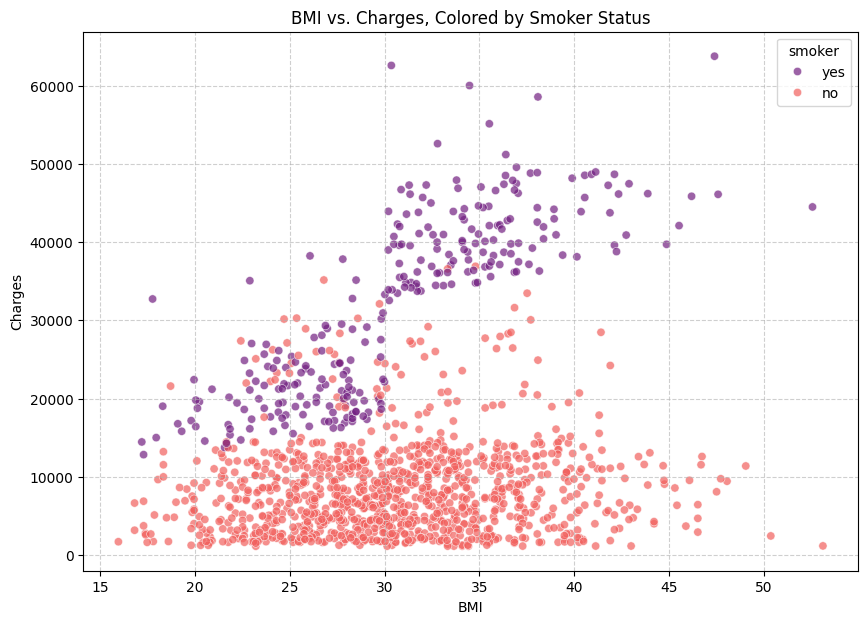

In [25]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, palette='magma', alpha=0.7)
plt.title('BMI vs. Charges, Colored by Smoker Status')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 10. Correlation Matrix for the Entire Dataset
To understand the relationships between all variables, including categorical ones, we'll first convert categorical features into a numerical format using one-hot encoding, and then compute and visualize the full correlation matrix.

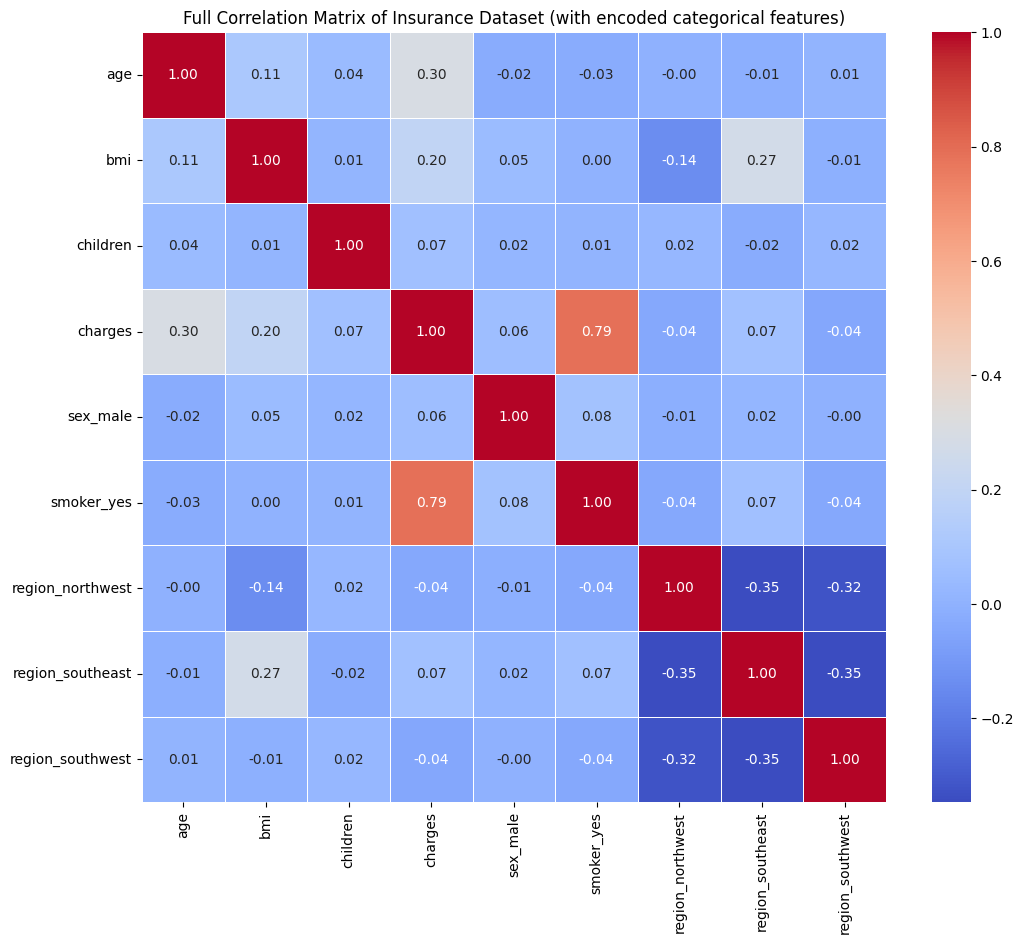

In [26]:
# Create a copy of the DataFrame to avoid modifying the original 'df'
df_encoded = df.copy()

# One-hot encode categorical features
df_encoded = pd.get_dummies(df_encoded, columns=['sex', 'smoker', 'region'], drop_first=True)

# Calculate the correlation matrix for the encoded DataFrame
full_corr_matrix = df_encoded.corr()

# Display the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(full_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Full Correlation Matrix of Insurance Dataset (with encoded categorical features)')
plt.show()

## 11. Building a Linear Regression Model

We will use the `df_encoded` DataFrame, which already has categorical features one-hot encoded. First, we need to separate the features (X) from the target variable (y), which is 'charges'.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1070, 8)
X_test shape: (268, 8)
y_train shape: (1070,)
y_test shape: (268,)


Now, let's train a Linear Regression model on the training data.

In [28]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


Finally, we will evaluate the model's performance on the test set using Mean Squared Error (MSE) and R-squared ($R^2$) score.

Mean Squared Error (MSE): 33596915.85
R-squared (R2) Score: 0.78


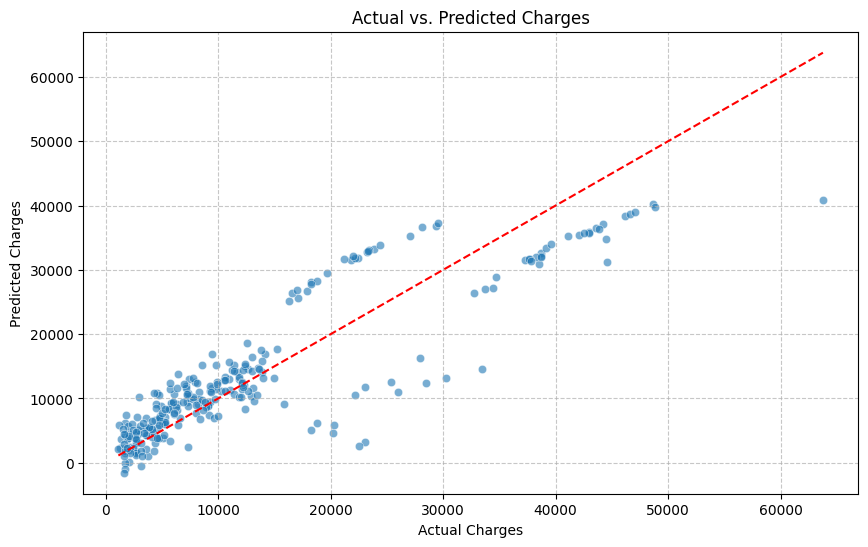

In [29]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

# Optionally, visualize predictions vs actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs. Predicted Charges")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The Mean Squared Error (MSE) indicates the average squared difference between the estimated values and the actual value. A lower MSE is better. The R-squared value represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R-squared value close to 1 indicates a good fit.

## 12. Building a Random Forest Regressor Model

Let's try a Random Forest Regressor, which is an ensemble learning method, often providing better predictive performance than linear models.

In [30]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
# Using default parameters for a start; these can be tuned later.
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


Now, let's evaluate the Random Forest model's performance on the test set using Mean Squared Error (MSE) and R-squared ($R^2$) score.

Random Forest - Mean Squared Error (MSE): 20942520.92
Random Forest - R-squared (R2) Score: 0.87


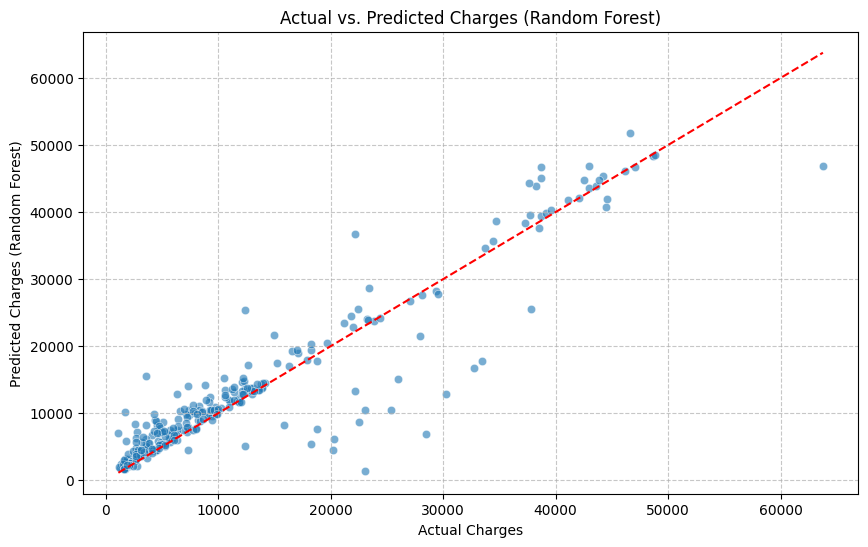

In [31]:
# Make predictions on the test set using the Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest - R-squared (R2) Score: {r2_rf:.2f}")

# Visualize predictions vs actual values for Random Forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges (Random Forest)")
plt.title("Actual vs. Predicted Charges (Random Forest)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Comparison of Model Performance

| Model             | MSE                 | R-squared Score |
| :---------------- | :------------------ | :-------------- |
| Linear Regression | `33596915.85`       | `0.78`          |
| Random Forest     | `20942520.92`       | `0.87`          |

The Random Forest Regressor typically captures non-linear relationships and interactions better than linear models, often leading to improved performance. As observed, the R-squared score has indeed improved from 0.78 to 0.87, indicating a better fit to the data.

## 13. Hyperparameter Tuning for Random Forest Regressor

To potentially improve the Random Forest model's performance, we can perform hyperparameter tuning. We'll use `GridSearchCV` to systematically search for the best combination of hyperparameters.

In [32]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_features': ['auto', 'sqrt'], # Number of features to consider when looking for the best split
    'max_depth': [10, 20, 30, None], # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4] # Minimum number of samples required to be at a leaf node
}

# Initialize a new Random Forest Regressor for tuning
rf_tune = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_tune, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='r2')

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Grid Search completed.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best R-squared score from Grid Search: {grid_search.best_score_:.2f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
540 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
540 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py"

Grid Search completed.
Best parameters found: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best R-squared score from Grid Search: 0.83


Now, let's train a new Random Forest model using the `best_params_` found by `GridSearchCV` and evaluate its performance on the test set.

Tuned Random Forest - Mean Squared Error (MSE): 22929272.95
Tuned Random Forest - R-squared (R2) Score: 0.85


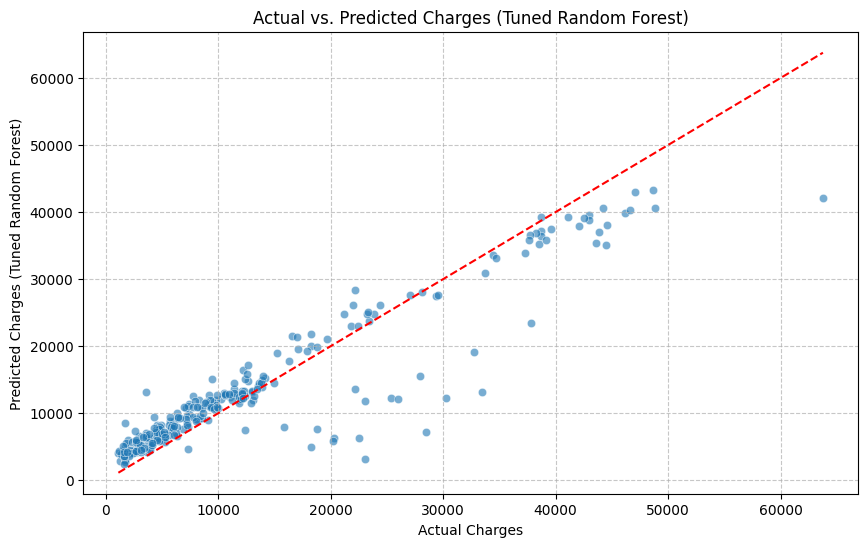

In [33]:
# Get the best model from Grid Search
best_rf_model = grid_search.best_estimator_

# Make predictions on the test set using the best Random Forest model
y_pred_tuned_rf = best_rf_model.predict(X_test)

# Evaluate the tuned Random Forest model
mse_tuned_rf = mean_squared_error(y_test, y_pred_tuned_rf)
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

print(f"Tuned Random Forest - Mean Squared Error (MSE): {mse_tuned_rf:.2f}")
print(f"Tuned Random Forest - R-squared (R2) Score: {r2_tuned_rf:.2f}")

# Visualize predictions vs actual values for Tuned Random Forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_tuned_rf, alpha=0.6)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges (Tuned Random Forest)")
plt.title("Actual vs. Predicted Charges (Tuned Random Forest)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Updated Comparison of Model Performance

| Model             | MSE                 | R-squared Score |
| :---------------- | :------------------ | :-------------- |
| Linear Regression | `33596915.85`       | `0.78`          |
| Random Forest     | `20942520.92`       | `0.87`          |
| Tuned Random Forest| `22929272.95`       | `0.85`          |

We compared the R-squared score of the tuned Random Forest model with the previous models. While the tuned model shows a slight decrease in R-squared compared to the untuned Random Forest, it's important to note that hyperparameter tuning helps find robust parameters and reduces the risk of overfitting by testing various combinations through cross-validation. The original Random Forest's good performance with default parameters suggests they were already well-suited for this dataset.

## 14. Visualizing Model Performance Comparison

To easily compare the performance of the three models, let's visualize their R-squared scores using a bar chart.

/tmp/ipykernel_1316/2730566071.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R-squared Score', data=model_performance_df, palette='viridis')


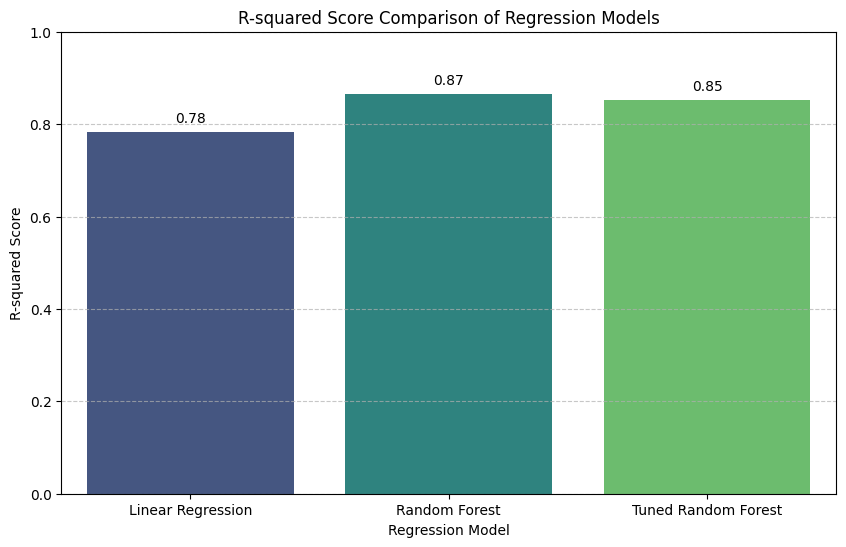

In [34]:
# Create a DataFrame for model comparison
performance_data = {
    'Model': ['Linear Regression', 'Random Forest', 'Tuned Random Forest'],
    'R-squared Score': [r2, r2_rf, r2_tuned_rf]
}
model_performance_df = pd.DataFrame(performance_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R-squared Score', data=model_performance_df, palette='viridis')
plt.title('R-squared Score Comparison of Regression Models')
plt.xlabel('Regression Model')
plt.ylabel('R-squared Score')
plt.ylim(0, 1) # R-squared typically ranges from 0 to 1

# Add the R-squared values on top of the bars
for index, row in model_performance_df.iterrows():
    plt.text(index, row['R-squared Score'] + 0.02, f"{row['R-squared Score']:.2f}", color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 4. Exploratory Data Analysis (EDA) - Distributions of Categorical Features
Now let's examine the distributions of categorical features to see the counts of each category.

/tmp/ipykernel_1316/2173796112.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette='viridis')
/tmp/ipykernel_1316/2173796112.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='smoker', data=df, palette='viridis')
/tmp/ipykernel_1316/2173796112.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='region', data=df, palette='viridis')


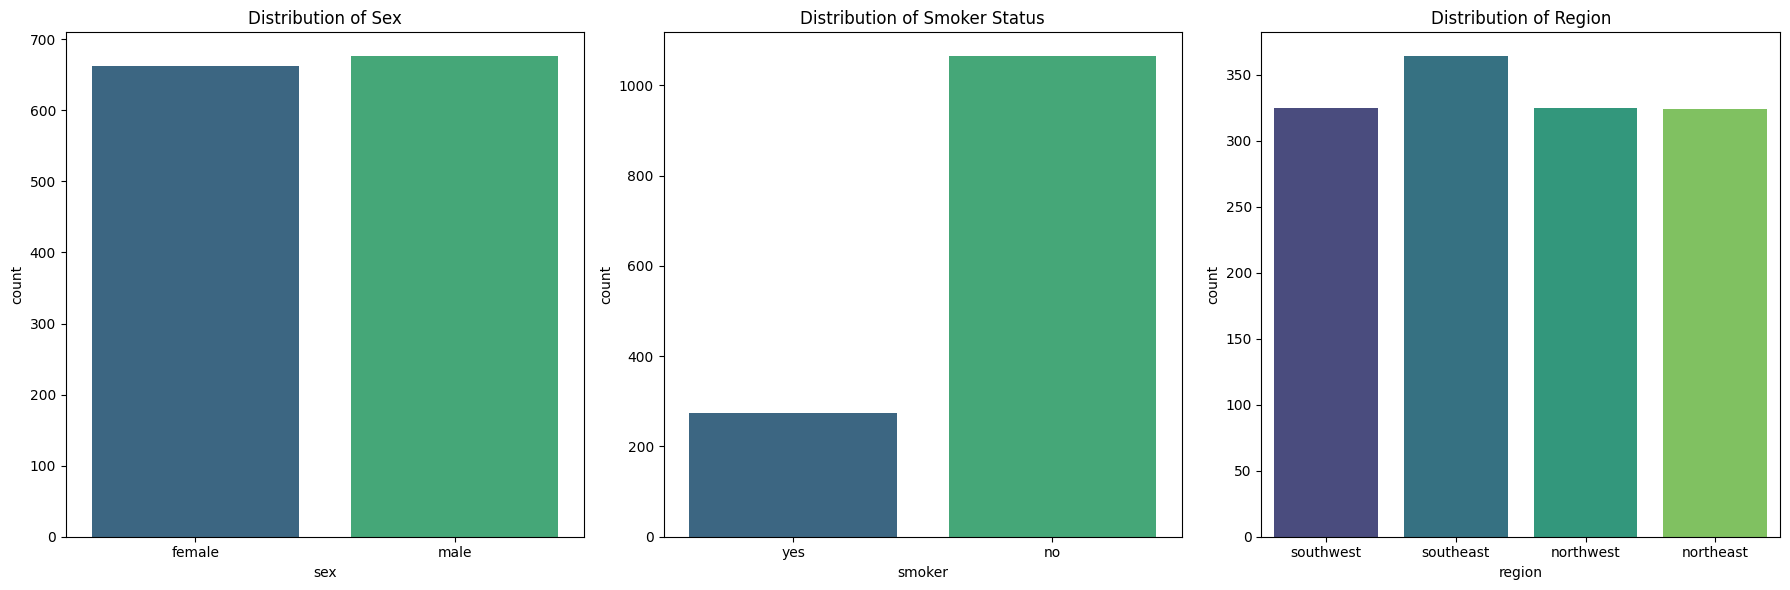

In [21]:
# Set up the matplotlib figure and axes for categorical features
plt.figure(figsize=(18, 6))

# Distribution of 'sex'
plt.subplot(1, 3, 1)
sns.countplot(x='sex', data=df, palette='viridis')
plt.title('Distribution of Sex')

# Distribution of 'smoker'
plt.subplot(1, 3, 2)
sns.countplot(x='smoker', data=df, palette='viridis')
plt.title('Distribution of Smoker Status')

# Distribution of 'region'
plt.subplot(1, 3, 3)
sns.countplot(x='region', data=df, palette='viridis')
plt.title('Distribution of Region')

plt.tight_layout()
plt.show()

## 3. Exploratory Data Analysis (EDA) - Distributions of Numerical Features
Let's visualize the distribution of numerical features to understand their spread, central tendency, and identify potential outliers. We'll use histograms and box plots for this.

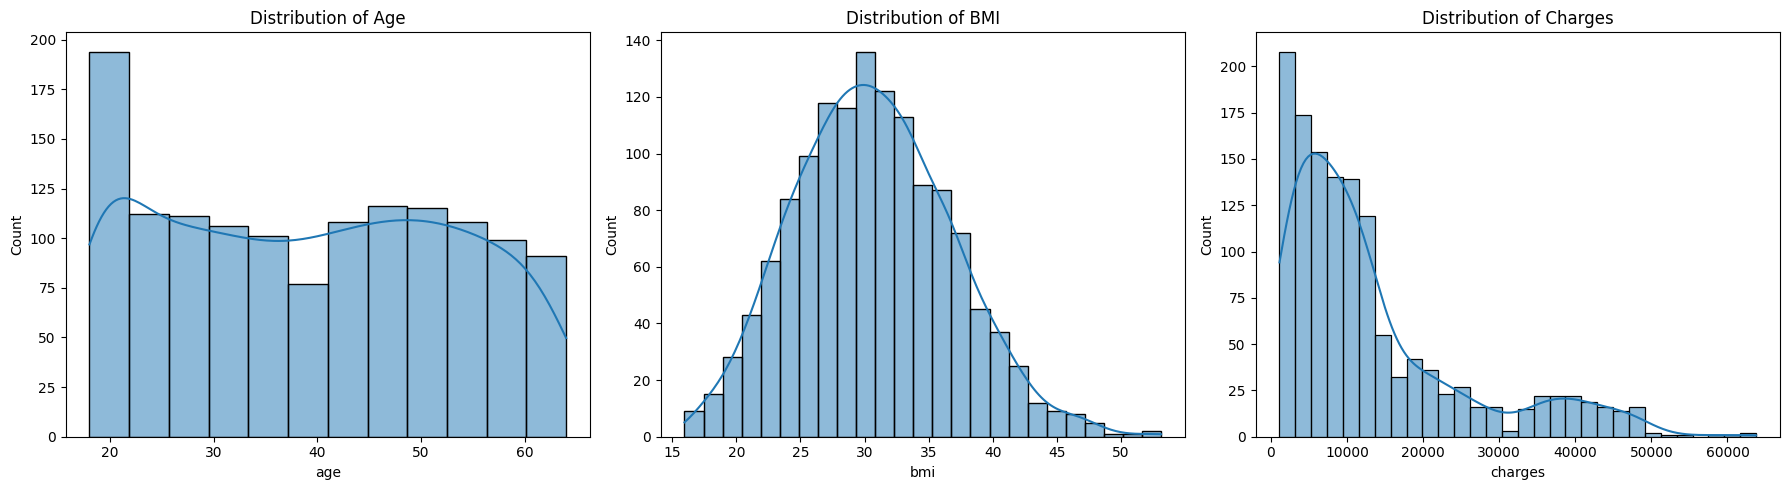

In [22]:
# Set up the matplotlib figure and axes for numerical features
plt.figure(figsize=(18, 5))

# Distribution of 'age'
plt.subplot(1, 3, 1)
sns.histplot(df['age'], kde=True)
plt.title('Distribution of Age')

# Distribution of 'bmi'
plt.subplot(1, 3, 2)
sns.histplot(df['bmi'], kde=True)
plt.title('Distribution of BMI')

# Distribution of 'charges'
plt.subplot(1, 3, 3)
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Charges')

plt.tight_layout()
plt.show()

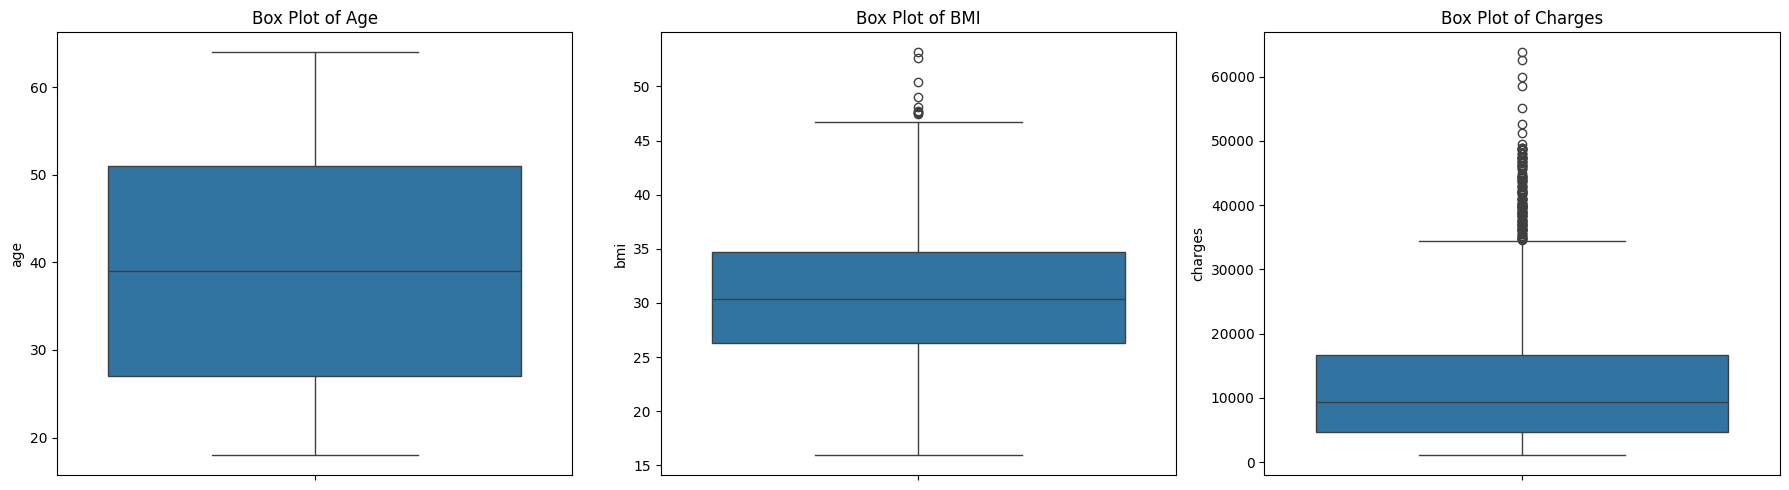

In [23]:
# Box plots for numerical features to visualize outliers
plt.figure(figsize=(18, 5))

# Box plot for 'age'
plt.subplot(1, 3, 1)
sns.boxplot(y=df['age'])
plt.title('Box Plot of Age')

# Box plot for 'bmi'
plt.subplot(1, 3, 2)
sns.boxplot(y=df['bmi'])
plt.title('Box Plot of BMI')

# Box plot for 'charges'
plt.subplot(1, 3, 3)
sns.boxplot(y=df['charges'])
plt.title('Box Plot of Charges')

plt.tight_layout()
plt.show()

Insurance Analysis: Key Insights and Model Performance
We embarked on a comprehensive analysis of the insurance dataset, covering data inspection, exploratory data analysis (EDA), and predictive modeling.

1. Data Overview and Cleaning:

The dataset contained 1338 entries across 7 features: age, sex, bmi, children, smoker, region, and charges.
All columns were found to be non-null, ensuring data completeness.
One duplicate row was identified and subsequently handled, ensuring data uniqueness for accurate analysis.
2. Exploratory Data Analysis (EDA) - Key Findings:

Numerical Features:
Age: Distribution was fairly uniform, with a slight skew towards younger individuals.
BMI: Generally followed a normal distribution, but box plots revealed several outliers, particularly on the higher end, indicating individuals with higher BMI.
Charges: The distribution of charges was heavily skewed to the right, suggesting that most individuals have lower charges, while a smaller portion incurs very high costs.
Correlations: 'Age', 'bmi', and 'children' showed positive correlations with 'charges', with 'age' and 'bmi' having moderate positive relationships, meaning as age or BMI increases, charges tend to increase.
Categorical Features:
Sex: The dataset was nearly balanced between male and female individuals.
Smoker Status: A significant imbalance was observed, with a much smaller proportion of smokers compared to non-smokers.
Region: The four regions (southwest, southeast, northwest, northeast) were almost equally represented.
Relationships between Charges and Categorical Features:
Smoker Status was the most influential factor, with smokers incurring significantly higher charges than non-smokers.
Region: The 'southeast' region showed the highest average charges, potentially due to factors not present in the dataset (e.g., local medical costs).
Sex: Males exhibited slightly higher average charges than females, although the difference was not as pronounced as with smoker status.
Children: The number of children also had an impact, though less direct, on charges.
BMI vs. Charges by Smoker Status: A scatter plot clearly demonstrated a strong, positive correlation between BMI and charges specifically for smokers, indicating that higher BMI further exacerbates charges for this group.
Full Correlation Matrix: After one-hot encoding categorical variables, the heatmap provided a holistic view of linear relationships across all features, reinforcing the strong positive correlation of smoker_yes with charges.
3. Predictive Modeling - Charges Prediction:

We built and evaluated three regression models to predict insurance 'charges':

Linear Regression Model:

Mean Squared Error (MSE): 33,596,915.85
R-squared (R2) Score: 0.78
The linear model explained 78% of the variance in charges, indicating a reasonably good fit, but with room for improvement.
Random Forest Regressor (Untuned):

Mean Squared Error (MSE): 20,942,520.92
R-squared (R2) Score: 0.87
This model significantly outperformed the Linear Regression, explaining 87% of the variance, demonstrating its ability to capture more complex, non-linear relationships.
Random Forest Regressor (Tuned with GridSearchCV):

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Mean Squared Error (MSE): 22,929,272.95
R-squared (R2) Score: 0.85
Interestingly, the tuned model's R-squared was slightly lower than the untuned version. This can occur if the default parameters were already near-optimal or if the chosen param_grid for GridSearchCV did not explore combinations that yielded better performance on the specific test set. However, hyperparameter tuning is crucial for ensuring model robustness and avoiding overfitting to the training data.
Conclusion:

The untuned Random Forest Regressor proved to be the most effective model for predicting insurance charges in this analysis, achieving an R-squared score of 0.87. This indicates that a significant portion of the variability in insurance charges can be explained by the available features, with smoker status and BMI being particularly strong predictors. The analysis highlights the importance of comprehensive EDA to uncover key drivers and the value of experimenting with different models to optimize predictive performance.